### PMPG method ###

Here we attempt to train PINNs for modelling lid driven cavity flow, where instead of minimizing the resiudals of the standard velocity-pressure formulation of navier stokes, one minimizes the given cost function:
$$\begin{equation} 
    C = \frac{1}{2} \int_{\Omega} ((\mathbb{u}\cdot\nabla)\mathbb{u} - \nu \nabla^2\mathbb{u})^2,
\end{equation}$$
subjected to the constraints
$$\begin{align}
\nabla \times ((\mathbb{u}\cdot\nabla)\mathbb{u} - \nu \nabla^2\mathbb{u}) = 0 \\
\nabla \cdot \mathbb{u} = 0 \\
\mathbb{u} \cdot \mathbb{n} = 0 \\
(\mathbb{u} - \mathbb{u}_{\text{bnd}}) = 0.
\end{align}
$$

It will make our life easier, if we express velocities using the stream function $\psi$, where $\mathbb{u} = (\partial_y \psi, -\partial_x \psi)$, as then constraint $(2)$ is satisfied automatically and constraint $(3)$ is achieved easily by hard-enforcing $\psi = 0$ on $\partial \Omega$. 

In [1]:
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
import sys
sys.path.append('../..')
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm
from typing import Tuple
from math import pi

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RE = 100
NU = 1 / RE
L_BOUNDS = [-0.5, -0.5, 0]
U_BOUNDS = [0.5, 0.5, 0.1]

In [4]:
def pde_res(psi: torch.Tensor, x: torch.Tensor):
    psi_grad = grad(psi, x, torch.ones_like(psi), create_graph=True)[0]
    u, v = psi_grad[:, 1:2], -psi_grad[:, 0:1]
    
    u_grad = grad(u, x, torch.ones_like(u), create_graph=True)[0]
    v_grad = grad(v, x, torch.ones_like(v), create_graph=True)[0]
    u_x, u_y, u_t = u_grad[:, 0:1], u_grad[:, 1:2], u_grad[:, 2:3]
    v_x, v_y, v_t = v_grad[:, 0:1], v_grad[:, 1:2], v_grad[:, 2:3]
    
    u_xx = grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
    u_yy = grad(u_y, x, torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
    v_xx = grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0][:, 0:1]
    v_yy = grad(v_y, x, torch.ones_like(v_y), create_graph=True)[0][:, 1:2]
    
    res_a = u_t + u * u_x + v * u_y - NU * (u_xx + u_yy)
    res_b = v_t + u * v_x + v * v_y - NU * (v_xx + v_yy)
        
    return res_a, res_b

In [5]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=3,
    device=device,
    int_sampling='Latin',
    N_int=4_000,
    N_sides=[(500, 500), (500, 500), (500, 0)],
)

domain = cb.CubeDomain(domain_ctx)

In [6]:
top_mask = torch.vstack([
        torch.zeros_like(domain.sides[0][0][:, 0:1]),
        torch.zeros_like(domain.sides[0][1][:, 0:1]),
        torch.zeros_like(domain.sides[1][0][:, 0:1]),
        torch.ones_like(domain.sides[1][1][:, 0:1]),
        torch.zeros_like(domain.sides[2][1][:, 0:1])
]).bool()

C = 1e6
eps = 0.01

def loss(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_pts = domain.interior.requires_grad_(True)
    pde_psi = model(pde_pts)
    pde_res_a, pde_res_b = pde_res(pde_psi, pde_pts)
    pde_loss = torch.mean(pde_res_a**2 + pde_res_b**2)
        
    pde_res_b_x = grad(pde_res_b, pde_pts, torch.ones_like(pde_res_b), create_graph=True)[0][:, 0:1]
    pde_res_a_y = grad(pde_res_a, pde_pts, torch.ones_like(pde_res_a), create_graph=True)[0][:, 1:2]
    eqm_loss = torch.mean((pde_res_b_x - pde_res_a_y - eps)**2)

    side_pts = torch.vstack([domain.sides[0][0], domain.sides[0][1], domain.sides[0][1], domain.sides[1][1], domain.sides[2][1]]).requires_grad_(True)
    side_psi = model(side_pts)
    side_psi_grad = grad(side_psi, side_pts, torch.ones_like(side_psi), create_graph=True)[0]
    side_u, side_v = side_psi_grad[:, 1:2], -side_psi_grad[:, 0:1]
    side_u[top_mask] -= 0.2
    side_loss = torch.mean((side_u - eps)**2 + (side_v - eps)**2)
    
    return [pde_loss, eqm_loss, C * side_loss]

In [7]:
model_ctx = mm.ModelContext(
    input_dim=3,
    output_dim=1,
    layer = [32, 32, 32],
    u_bounds=U_BOUNDS,
    l_bounds=L_BOUNDS
)

model = mm.MLPModel(model_ctx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=loss,
    resample=False,
    epochs=5_000
)

total_loss_values_1, component_loss_values_1 = train.simple_train(train_ctx)

/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/libtorch_1745854776362/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Loss at epoch 1 is: 15165.2041015625. 
Loss at epoch 100 is: 3047.117919921875. 
Loss at epoch 200 is: 1002.2632446289062. 
Loss at epoch 300 is: 512.9629516601562. 
Loss at epoch 400 is: 397.778564453125. 
Loss at epoch 500 is: 337.7453918457031. 
Loss at epoch 600 is: 366.60394287109375. 
Loss at epoch 700 is: 276.1722412109375. 
Loss at epoch 800 is: 271.92840576171875. 
Loss at epoch 900 is: 252.89060974121094. 
Loss at epoch 1000 is: 242.8367462158203. 
Loss at epoch 1100 is: 241.59925842285156. 
Loss at epoch 1200 is: 233.7677459716797. 
Loss at epoch 1300 is: 268.7289733886719. 
Loss at epoch 1400 is: 246.80975341796875. 
Loss at epoch 1500 is: 225.9205322265625. 
Loss at epoch 1600 is: 226.72122192382812. 
Loss at epoch 1700 is: 280.0528869628906. 
Loss at epoch 1800 is: 284.873779296875. 
Loss at epoch 1900 is: 225.51597595214844. 
Loss at epoch 2000 is: 217.48219299316406. 
Loss at epoch 2100 is: 216.51585388183594. 
Loss at epoch 2200 is: 231.7067108154297. 
Loss at epoch 23

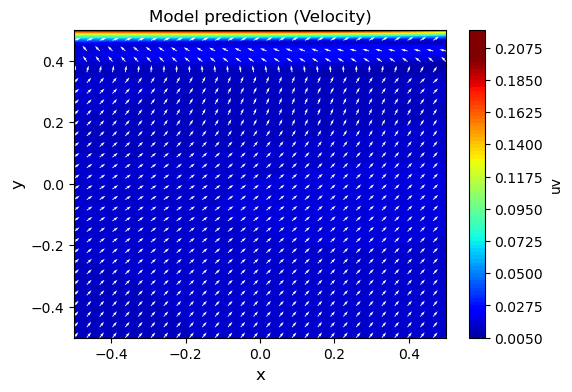

[tensor(0.1400, device='cuda:0', grad_fn=<MeanBackward0>), tensor(27.9191, device='cuda:0', grad_fn=<MeanBackward0>), tensor(181.9084, device='cuda:0', grad_fn=<MulBackward0>)]


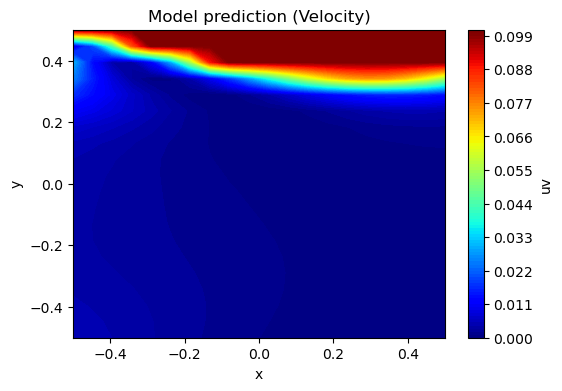

In [10]:
T_test = 0.1

# define plot context
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    function_names = ['uv'],
    titles= ['Model prediction (Velocity)'],
    device=device,
    vmin=0,
    vmax=0.2,
    patches=[],
    N=20
)

def append_time(x, t):
    return torch.column_stack([x, torch.full_like(x[:, 0:1], t)])

def velocity(x: torch.Tensor) -> torch.Tensor:
    x = append_time(x, T_test).requires_grad_(True)
    psi = model(x)
    psi_grad = grad(psi, x, torch.ones_like(psi))[0]
    
    return torch.cat([psi_grad[:, 1:2], -psi_grad[:, 0:1]], dim=1)

def residuals(x):
    x = append_time(x, T_test).requires_grad_(True)
    psi = model(x)
    res_a, res_b = pde_res(psi, x)
    
    pde_res_b_x = grad(res_b, x, torch.ones_like(res_b), create_graph=True)[0][:, 1:2]
    pde_res_a_y = grad(res_a, x, torch.ones_like(res_a), create_graph=True)[0][:, 0:1]
    
    losses = loss(model, domain)
    
    print(losses)
    
    #return torch.clamp((pde_res_a_y - pde_res_b_x)**2, 0.0, 0.1)
    return torch.clamp(res_a**2 + res_b**2, 0.0, 0.1)

#utils.plot_vector_field_2d([model], plot_ctx, N=100, n_width=30, n_heigth=30)
utils.plot_vector_field_2d([velocity], plot_ctx, N=100, n_width=30, n_heigth=30)

plot_ctx.vmax = 0.1

utils.plot_function_on_2d_cube([residuals], plot_ctx)


plot_ctx.vmin=0
plot_ctx.vmax=1
plot_ctx.titles = ['Model prediction (Voricity)']
plot_ctx.function_names = [r'$\omega$']

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/cavity_flow/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


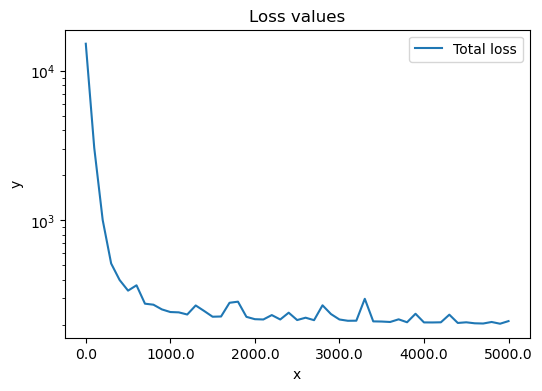

In [11]:
plot_ctx.titles = ["Loss values"]
utils.plot_loss_values({'Total loss': total_loss_values_1}, plot_ctx)